# Импорты библиотек

In [42]:
!pip install gdown
!pip install umap-learn
!pip install --upgrade git+https://github.com/MedMNIST/MedMNIST.git
!gdown https://drive.google.com/uc?id=1qv9M3g0JnY76ZTwnX8_AmKWH9wngdOYz 
!gdown https://drive.google.com/uc?id=1q0s2-c_QGQqvGLmU5EDAp9LX5SIr9R7U

  Cloning https://github.com/MedMNIST/MedMNIST.git to /tmp/pip-req-build-ilo_i431
  Running command git clone -q https://github.com/MedMNIST/MedMNIST.git /tmp/pip-req-build-ilo_i431
Access denied with the following error:

 	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses. 

You may still be able to access the file from the browser:

	 https://drive.google.com/uc?id=1qv9M3g0JnY76ZTwnX8_AmKWH9wngdOYz 

Downloading...
From: https://drive.google.com/uc?id=1q0s2-c_QGQqvGLmU5EDAp9LX5SIr9R7U
To: /content/fetal_health.csv
100% 229k/229k [00:00<00:00, 21.9MB/s]


In [43]:
!pip install scikit-learn==0.22.2.post1

In [44]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sklearn
import umap
import medmnist
import dataset_without_pytorch
import time
import warnings


from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import manifold
from medmnist import INFO, Evaluator
from mlxtend.feature_selection import SequentialFeatureSelector 

matplotlib.style.use('ggplot')
%matplotlib inline
warnings.filterwarnings("ignore")

# Задание 1. Корреляции в случайных данных

Как Вам рассказали на лекции - в большом количество случайных данных почти всегда можно найти корреляции. Давайте это проверим!

Пусть у нас есть 5000 случайных величин $X_i$ подчиняющихся нормальному распределению $N(0,1)$. 
1. Семплируйте по 40 значений для каждой из них. Для этого воспользуйтесь функцией np.random.normal

2. Разбейте полученные значения для каждой случайной величины на выборку для обучения и на тестовую в соотношении 1 к 1. У Вас должны в итоге получиться две матрицы статистик $A, B$ с размерностями (5000 x 20) и (5000 x 20)

3. Подсчитайте на основе полученных статистик из матрицы $A$ матрицу корреляций для случайных величин. Должна получиться матрица 5000 * 5000. Используйте функцию np.corrcoef.

4. Замените диагональные элементы на нули и найдите в полученной матрице максимальное значение. Строка $i$ и столбец $j$ соответствуют случайным величинам $X_i X_j$ для семплированных данных которых корреляция оказалась наивысшей. Отобразите значения $X_i X_j$ на графике. Выведите значения наибольшой корреляции

In [45]:
A=np.random.normal(0,1,size=(5000,20))
B=np.random.normal(0,1,size=(5000,20))
print(A.shape, B.shape)
Rs=np.corrcoef(A)
Rs.shape

(5000, 20) (5000, 20)


(5000, 5000)

In [48]:
tmp=Rs-Rs*np.diag(np.ones(Rs.shape[0]))
ind = np.unravel_index(np.argmax(tmp, axis=None), tmp.shape)
tmp[ind],ind

(0.8861915492883292, (1219, 2287))

Очевидно, что никакой причинно следственной связи в этом нет. Давайте в этом убедимся. Для этого подсчитайте и выведите значение корреляции между $X_i$ и $X_j$ на основе данных их матрицы $B$. Используйте функцию scipy.stats.pearsonr. Отобразите значения найденных переменных $X_i$ и $X_j$ из матрицы $B$. У Вас должна получиться очень маленькая корреляция (мб даже отрицательная)

In [51]:
from scipy.stats import pearsonr

print("A:",pearsonr(A[1219],A[2287]))
print("B:",pearsonr(B[1219],B[2287]))

A: (0.8861915492883289, 1.9990610837866622e-07)
B: (0.04468054742415627, 0.8516260863559391)


Действительно можно получить и отрицательную, но в последней иттерации у меня получилась положительная но очень маленькая корреляция.

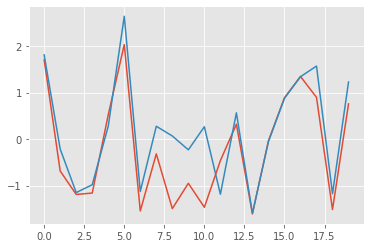

In [58]:
plt.plot(A[1219])
plt.plot(A[2287])

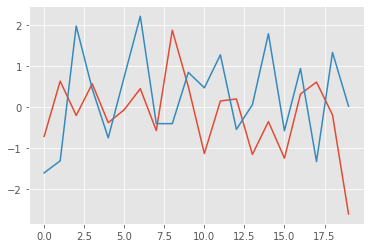

In [59]:
plt.plot(B[1219])
plt.plot(B[2287])

Действительно можно получить и отрицательную, но в последней иттерации у меня получилась положительная но очень маленькая корреляция.

# Задание 2. Методы понижения размерности

Примените методы понижения размерности: PCA, t-SNE и UMAP к изображениям клеток крови из датасета BloodMNIST. Отобразите проекцию данных на две главные компоненты. Какой метод позволяет лучше разделить данные в пространстве? Опишите ваши наблюдения

Произведем загрузку данных:

In [60]:
data_flag = 'bloodmnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(dataset_without_pytorch, info['python_class'])

# load the data
bloodmnist = DataClass(split='train', download=download)
print(bloodmnist)

  0%|          | 0/35461855 [00:00<?, ?it/s]

Dataset BloodMNIST (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License: CC BY 4.0


Доступ к данным идет посредством обращения к ключу blodmnist.imgs, доступ к разметке классов через blodmnist.labels

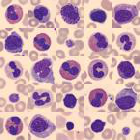

In [61]:
X = bloodmnist.imgs/255.
X = X.reshape(-1, 2352)#
Y = bloodmnist.labels
 
bloodmnist.montage(length=5)

In [62]:
from sklearn.decomposition import PCA

mean = np.mean(X, axis=0)
centered_X = X-mean

pca_blood=sklearn.decomposition.PCA()
pca_blood.fit(centered_X)

PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
    svd_solver='auto', tol=0.0, whiten=False)

(11959, 2352)

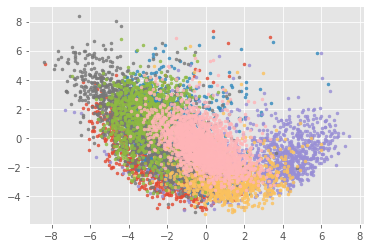

In [63]:
X_r = pca_blood.transform(centered_X)
for i in range(int(min(Y)),int(max(Y))):
  plt.scatter(X_r[Y.reshape(-1) == i, 0], X_r[Y.reshape(-1) == i, 1], alpha=0.8,marker='.')
X_r.shape

Думаю по данной картинке можно сделать вывод, что этот метод лучше не применять здесь, так как классификации как таковой тут сделать нельзя(ну или почти нельзя).

In [64]:
import sklearn.manifold

model = sklearn.manifold.TSNE(n_components = 2, init = X_r[:, 0:2], perplexity=40, verbose = 2)
manifold = model.fit_transform(X_r)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 11959 samples in 3.582s...
[t-SNE] Computed neighbors for 11959 samples in 608.154s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11959
[t-SNE] Computed conditional probabilities for sample 2000 / 11959
[t-SNE] Computed conditional probabilities for sample 3000 / 11959
[t-SNE] Computed conditional probabilities for sample 4000 / 11959
[t-SNE] Computed conditional probabilities for sample 5000 / 11959
[t-SNE] Computed conditional probabilities for sample 6000 / 11959
[t-SNE] Computed conditional probabilities for sample 7000 / 11959
[t-SNE] Computed conditional probabilities for sample 8000 / 11959
[t-SNE] Computed conditional probabilities for sample 9000 / 11959
[t-SNE] Computed conditional probabilities for sample 10000 / 11959
[t-SNE] Computed conditional probabilities for sample 11000 / 11959
[t-SNE] Computed conditional probabilities for sample 11959 / 11959
[t-SNE] Mean sigma: 1.569475
[t-SNE] Computed c

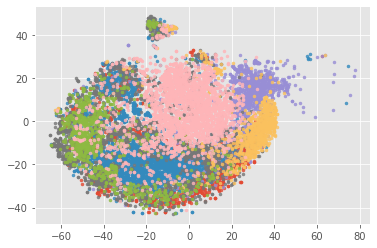

In [65]:
for i in range(int(min(Y)),int(max(Y))):
  plt.scatter(manifold[Y.reshape(-1) == i, 0], manifold[Y.reshape(-1) == i, 1], alpha=0.8,marker='.')

In [66]:
import warnings
warnings.filterwarnings("ignore")
from umap import UMAP

model = UMAP(n_components = 2, min_dist = 1, n_neighbors = 93, init = X_r[:, 0:2], n_epochs = 1000, verbose = 2)
umap = model.fit_transform(X_r)

UMAP(init=array([[ 7.72601927, 2.51092616],
       [-4.97371104, 3.2243819 ],
       [ 1.6063136 , -1.94856355],
       ...,
       [-2.84528072, -0.82814101],
       [-0.96777763, 0.64958385],
       [ 1.60302842, -2.95331448]]), min_dist=1, n_epochs=1000, n_neighbors=93, verbose=2)
Tue Apr  5 15:43:59 2022 Construct fuzzy simplicial set
Tue Apr  5 15:43:59 2022 Finding Nearest Neighbors
Tue Apr  5 15:43:59 2022 Building RP forest with 10 trees
Tue Apr  5 15:44:03 2022 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Tue Apr  5 15:45:09 2022 Finished Nearest Neighbor Search
Tue Apr  5 15:45:12 2022 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

Tue Apr  5 15:46:49 2022 Finished embedding


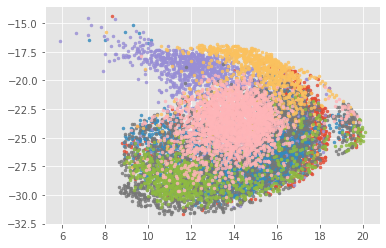

In [ ]:
for i in range(int(min(Y)),int(max(Y))):
  plt.scatter(umap[Y.reshape(-1) == i, 0], umap[Y.reshape(-1) == i, 1], alpha=0.8,marker='.')

Помоему все методы достаточно плохо работают в данном случае, tSNE вообще ужасен, т.к. долгий, а результат получается весьма похож на UMAP(визуально), но UMAP быстрее в 10 раз примерно. В общем во всех случаях видны взаимные включения различных классов

# Задание 3. Feature selection и feature engineering

В этом задании используя датасет с [данными о здоровье плода](https://www.kaggle.com/andrewmvd/fetal-health-classification), сравните различные подходы к отбору признаков. Загрузим датасет:

In [67]:
data = pd.read_csv("fetal_health.csv")
data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


Посмотрим на данные. Видно, что среди представленных признаков довольно много скоррелированных:

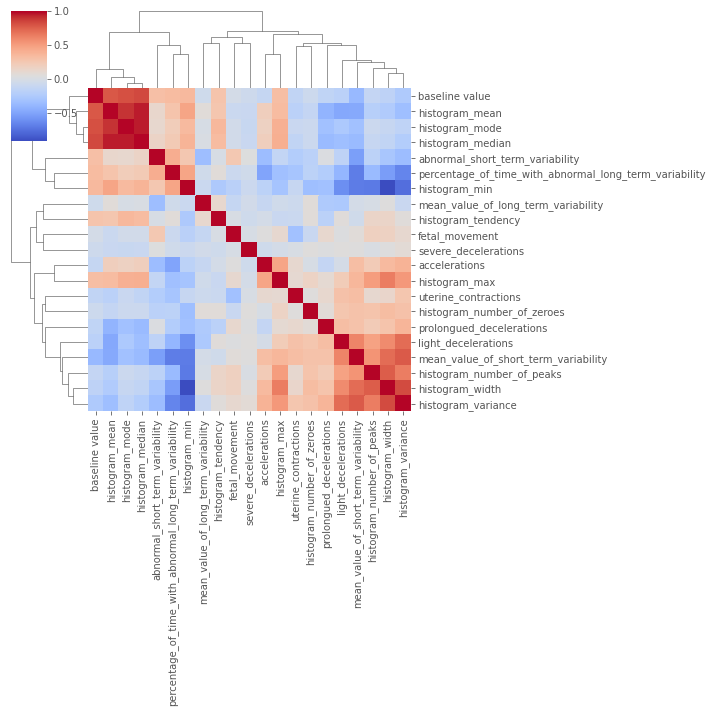

In [68]:
X = data.drop('fetal_health', axis=1)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index= X.index)
Y = data['fetal_health']

corr_matrix = X.corr(method='spearman')
res = sns.clustermap(corr_matrix, method='weighted', figsize=(10, 10), cmap='coolwarm')

Используя жадный отбор признаков, Add Del и PCA, отберите/сгенерируйте от 1 до 20 признаков и сравните на кросс-валидации `accuracy` для моделей `SVC(kernel='rbf')`, получающихся в процессе отбора/генерации признаков. Сравните полученные результаты с `accuracy` модели, обученной с использованием всех имеющихся признаков (на кросс-валидации с тем же количеством фолдов). Изобразите результаты в виде графика, опишите свои наблюдения.

In [69]:
pca_fetal=sklearn.decomposition.PCA()
pca_fetal.fit(X)
X_pca=pca_fetal.transform(X)
X.shape

(2126, 21)

In [70]:
from mlxtend.feature_selection import SequentialFeatureSelector
from tqdm.notebook import tqdm
from sklearn.model_selection import cross_validate

acc=[]
acc_d=[]

for k_f in tqdm(range(1,20)):
  sffs = SequentialFeatureSelector(
            SVC(kernel='rbf'),
            k_features = k_f,
            forward=True, 
            floating=True, 
            verbose=0,
            scoring='accuracy',
            cv=5)
  sffs.fit(X_pca,Y)
  X_pca_cut=sffs.transform(X_pca)
  tmp=cross_validate(SVC(kernel='rbf'),X_pca_cut,Y,scoring='accuracy')
  acc.append(tmp['test_score'].mean())
  acc_d.append( ((tmp['test_score']-acc[-1])**2).mean()**0.5 )

  0%|          | 0/19 [00:00<?, ?it/s]

<ErrorbarContainer object of 3 artists>

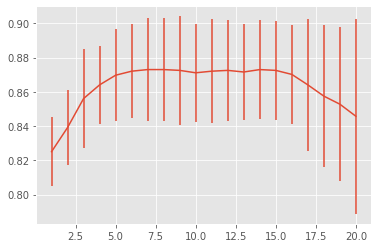

In [71]:
tmp=cross_validate(SVC(kernel='rbf'),X_pca,Y,scoring='accuracy')
acc.append(tmp['test_score'].mean())
acc_d.append( ((tmp['test_score']-acc[-1])**2).mean()**0.5 )
plt.errorbar(range(1,21),acc,yerr=acc_d)

Начиная с 16 признаков модель видимо уходит в переобучение, вероятно это связано с малым коллическом признаков. Однако с 5 признаков уже наступает нормальная работа модели. Но сам метод очень длительный.

# Задание 4. Использование понижения размерности для ускорения обучения

Рассмотрите набор данных TissueMNIST. В этом задании вам нужно сравнить производительность двух моделей: обученной с использованием всех доступных признаков и обученной на данных пониженной размерности. От вас требуется:

1. Посторить модель `RandomForestClassifier()` и обучить ее на тренировочной выборке, оценить `accuracy` модели на тестовой выборке и время, потраченное на обучение;
2. Построить модель PCA на тренировочных данных и определите число главных компонент, объясняющих 90% дисперсии (или используйте любой другой способ выбора оптимального числа главных компонент, разбиравшийся на лекции);
3. Спроецировать данные тестовой выборки на главные компоненты, полученной модели PCA;
4. Построить модель `RandomForestClassifier()` и обучить ее на данных пониженной размерности, оценить `accuracy` модели на тестовой выборке и время, потраченное на обучение;
5. Опишите ваши наблюдения, сделайте выводы.

In [72]:
data_flag = 'tissuemnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(dataset_without_pytorch, info['python_class'])

# load the data
tissuemnist = DataClass(split='test', download=download)
print(tissuemnist)

X = tissuemnist.imgs/255.
X = X.reshape(-1, 784)
Y = tissuemnist.labels
 
tissuemnist.montage(length=5)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

  0%|          | 0/124962739 [00:00<?, ?it/s]

Dataset TissueMNIST (tissuemnist)
    Number of datapoints: 47280
    Root location: /root/.medmnist
    Split: test
    Task: multi-class
    Number of channels: 1
    Meaning of labels: {'0': 'Collecting Duct, Connecting Tubule', '1': 'Distal Convoluted Tubule', '2': 'Glomerular endothelial cells', '3': 'Interstitial endothelial cells', '4': 'Leukocytes', '5': 'Podocytes', '6': 'Proximal Tubule Segments', '7': 'Thick Ascending Limb'}
    Number of samples: {'train': 165466, 'val': 23640, 'test': 47280}
    Description: We use the BBBC051, available from the Broad Bioimage Benchmark Collection. The dataset contains 236,386 human kidney cortex cells, segmented from 3 reference tissue specimens and organized into 8 categories. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. Each gray-scale image is 32×32×7 pixels, where 7 denotes 7 slices. We take maximum values across the slices and resize them into 28×28 gray-scale images.
    License: CC BY 3

In [73]:
rng = np.random.RandomState(42)
rf = RandomForestClassifier(n_estimators=200, random_state=rng)

start = time.time()
rf.fit(X_train, Y_train)
end = time.time() - start

In [74]:
print('Time work ', int(end // 60), ':', int((end % 60)*100)/100, sep = '')
y_pred = rf.predict(X_test)
print('Accuracy ', accuracy_score(y_pred, Y_test))

Time work 2:45.58
Accuracy  0.5341582064297801


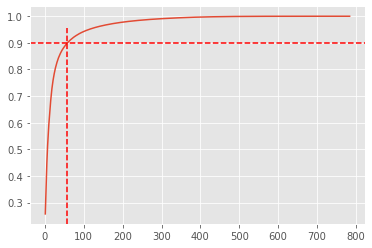

In [75]:
plt.figure()
pca = sklearn.decomposition.PCA(n_components=X_train.shape[1])
pca.fit(X_train)

ths = 0.90
total_explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(np.arange(1, total_explained.shape[0] + 1), total_explained)
plt.axhline(xmin=0, xmax=1000, y=0.9, c="red", ls="--")
chosen_number = np.where(total_explained >= 0.9)[0][0] + 1
plt.axvline(x=chosen_number, ymin=0, ymax=0.9, c="red", ls="--")

plt.show()

In [76]:
pca = sklearn.decomposition.PCA(n_components=chosen_number)
pca.fit(X_train)
X_reduced_pca = pca.transform(X_train)

model_PCA = RandomForestClassifier(n_estimators=200, random_state=rng)

start = time.time()
model_PCA.fit(X_reduced_pca,Y_train)
T = time.time() - start

In [77]:
print('Time work ', int(T // 60), ':', int((T % 60)*100)/100, sep = '')
X_test_reduced = pca.transform(X_test)
y_pred = model_PCA.predict(X_test_reduced)
print('Accuracy ', accuracy_score(y_pred, Y_test))

Time work 1:26.7
Accuracy  0.505922165820643


Точность получилась примерно такой же, но для этого понадобилось почти в два раза меньше времени, что не может не радовать.